# Doo — 상위 모델 5-fold 교차검증

Validation 단일 분할 결과가 우연이 아닌지 확인하기 위해 Train 데이터 내부에서 상위 세 모델을 5-fold 교차검증합니다.

- XGBoost: 선택 임계값 F1 최고
- Random Forest: 높은 Recall과 F1
- Soft Voting: ROC-AUC 최고

각 고객은 정확히 한 번 검증 Fold에 포함되며, 이때 얻은 Out-of-Fold 확률로 임계값도 비교합니다. Test 데이터는 사용하지 않습니다.

## 0. 데이터 로드

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost

from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "data" / "preprocessed").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("data/preprocessed 폴더를 찾을 수 없음")
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "preprocessed"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]

print("XGBoost version:", xgboost.__version__)
print("X_train:", X_train.shape, "| 이탈률:", y_train.mean().round(3))

XGBoost version: 3.3.0
X_train: (2592, 10) | 이탈률: 0.494


## 1. 교차검증용 모델 정의

외부 5-fold 교차검증에서 병렬 처리를 사용하므로 각 내부 모델의 `n_jobs=1`로 중첩 병렬 실행을 방지합니다.

In [2]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

def make_random_forest():
    return RandomForestClassifier(
        n_estimators=500, max_depth=8, min_samples_leaf=5,
        max_features="sqrt", class_weight="balanced",
        random_state=42, n_jobs=1,
    )

def make_xgboost():
    return XGBClassifier(
        n_estimators=300, learning_rate=0.03, max_depth=3, min_child_weight=5,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, n_jobs=1, verbosity=0,
    )

def make_calibrated_svc():
    return CalibratedClassifierCV(
        estimator=SVC(
            C=1.0, kernel="rbf", gamma="scale",
            class_weight="balanced", random_state=42,
        ),
        method="sigmoid", cv=5, ensemble=False,
    )

def make_soft_voting():
    return VotingClassifier(
        estimators=[
            ("logistic", LogisticRegression(max_iter=1000, random_state=42)),
            ("random_forest", make_random_forest()),
            ("xgboost", make_xgboost()),
            ("svc", make_calibrated_svc()),
        ],
        voting="soft", weights=[1, 1, 1, 1], n_jobs=1,
    )

cross_validation_models = {
    "XGBoost": make_xgboost,
    "Random Forest": make_random_forest,
    "Soft Voting": make_soft_voting,
}

## 2. Stratified 5-fold 실행

각 Fold의 Train/Validation 점수를 기록하고, 전체 Train 고객에 대한 Out-of-Fold 확률을 생성합니다.

In [3]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

cross_validation_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_validation_fold_results = []
cross_validation_oof_probabilities = {}

for model_name, model_factory in cross_validation_models.items():
    model_oof_proba = np.zeros(len(X_train), dtype=float)
    print(f"\n[{model_name}]")

    for fold_number, (fold_train_idx, fold_val_idx) in enumerate(
        cross_validation_splitter.split(X_train, y_train), start=1
    ):
        fold_model = model_factory()
        fold_X_train = X_train.iloc[fold_train_idx]
        fold_y_train = y_train.iloc[fold_train_idx]
        fold_X_val = X_train.iloc[fold_val_idx]
        fold_y_val = y_train.iloc[fold_val_idx]

        fold_model.fit(fold_X_train, fold_y_train)
        fold_train_pred = fold_model.predict(fold_X_train)
        fold_val_pred = fold_model.predict(fold_X_val)
        fold_val_proba = fold_model.predict_proba(fold_X_val)[:, 1]
        model_oof_proba[fold_val_idx] = fold_val_proba

        cross_validation_fold_results.append({
            "model": model_name,
            "fold": fold_number,
            "train_accuracy": accuracy_score(fold_y_train, fold_train_pred),
            "val_accuracy": accuracy_score(fold_y_val, fold_val_pred),
            "recall": recall_score(fold_y_val, fold_val_pred),
            "precision": precision_score(fold_y_val, fold_val_pred),
            "f1": f1_score(fold_y_val, fold_val_pred),
            "roc_auc": roc_auc_score(fold_y_val, fold_val_proba),
        })
        print(f"Fold {fold_number}: F1={f1_score(fold_y_val, fold_val_pred):.3f}, ROC-AUC={roc_auc_score(fold_y_val, fold_val_proba):.3f}")

    cross_validation_oof_probabilities[model_name] = model_oof_proba

cross_validation_fold_df = pd.DataFrame(cross_validation_fold_results)
print("\n5-fold 교차검증 완료")


[XGBoost]
Fold 1: F1=0.710, ROC-AUC=0.760
Fold 2: F1=0.742, ROC-AUC=0.803
Fold 3: F1=0.707, ROC-AUC=0.749
Fold 4: F1=0.721, ROC-AUC=0.784
Fold 5: F1=0.702, ROC-AUC=0.775

[Random Forest]
Fold 1: F1=0.703, ROC-AUC=0.768
Fold 2: F1=0.735, ROC-AUC=0.797
Fold 3: F1=0.708, ROC-AUC=0.758
Fold 4: F1=0.722, ROC-AUC=0.785
Fold 5: F1=0.719, ROC-AUC=0.778

[Soft Voting]
Fold 1: F1=0.683, ROC-AUC=0.762
Fold 2: F1=0.753, ROC-AUC=0.812
Fold 3: F1=0.690, ROC-AUC=0.752
Fold 4: F1=0.705, ROC-AUC=0.786
Fold 5: F1=0.702, ROC-AUC=0.772

5-fold 교차검증 완료


## 3. Fold 평균과 표준편차 비교

평균은 전반적인 성능, 표준편차는 데이터 분할에 따른 안정성을 나타냅니다.

In [4]:
cross_validation_summary_df = (
    cross_validation_fold_df.groupby("model")
    .agg(
        train_accuracy_mean=("train_accuracy", "mean"),
        val_accuracy_mean=("val_accuracy", "mean"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
    )
    .assign(train_val_gap=lambda frame: frame["train_accuracy_mean"] - frame["val_accuracy_mean"])
    .sort_values(["f1_mean", "roc_auc_mean"], ascending=False)
    .reset_index()
)
display(cross_validation_summary_df.style.format({column: "{:.3f}" for column in cross_validation_summary_df.columns if column != "model"}))

,model,train_accuracy_mean,val_accuracy_mean,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,train_val_gap
0,Random Forest,0.802,0.703,0.765,0.015,0.676,0.018,0.718,0.013,0.777,0.015,0.099
1,XGBoost,0.763,0.705,0.754,0.012,0.683,0.023,0.716,0.016,0.774,0.021,0.058
2,Soft Voting,0.747,0.699,0.736,0.035,0.680,0.024,0.707,0.027,0.777,0.024,0.048


## 4. Out-of-Fold 임계값 비교

각 고객을 학습에 사용하지 않은 Fold 모델이 예측한 확률만 모아 임계값을 선택합니다. Recall 0.80 이상 후보 중 F1-score가 가장 높은 값을 사용합니다.

In [5]:
cross_validation_thresholds = np.arange(0.30, 0.71, 0.05)
cross_validation_oof_threshold_rows = []

for model_name, oof_proba in cross_validation_oof_probabilities.items():
    for threshold in cross_validation_thresholds:
        oof_pred = (oof_proba >= threshold).astype(int)
        cross_validation_oof_threshold_rows.append({
            "model": model_name,
            "threshold": threshold,
            "recall": recall_score(y_train, oof_pred),
            "precision": precision_score(y_train, oof_pred, zero_division=0),
            "f1": f1_score(y_train, oof_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_train, oof_proba),
            "predicted_churn_count": int(oof_pred.sum()),
        })

cross_validation_oof_threshold_df = pd.DataFrame(cross_validation_oof_threshold_rows)
cross_validation_selected_rows = []
for model_name, model_rows in cross_validation_oof_threshold_df.groupby("model"):
    candidates = model_rows[model_rows["recall"] >= 0.80]
    selected = candidates.loc[candidates["f1"].idxmax()] if not candidates.empty else model_rows.loc[model_rows["f1"].idxmax()]
    cross_validation_selected_rows.append(selected)

cross_validation_selected_df = (
    pd.DataFrame(cross_validation_selected_rows)
    .sort_values(["f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
display(cross_validation_selected_df.style.format({
    "threshold": "{:.2f}", "recall": "{:.3f}",
    "precision": "{:.3f}", "f1": "{:.3f}", "roc_auc": "{:.3f}",
}))

,model,threshold,recall,precision,f1,roc_auc,predicted_churn_count
0,Soft Voting,0.35,0.884,0.630,0.736,0.775,1798
1,XGBoost,0.35,0.891,0.625,0.735,0.773,1826
2,Random Forest,0.45,0.820,0.664,0.734,0.776,1579


## 5. Fold별 안정성과 평균 성능 시각화

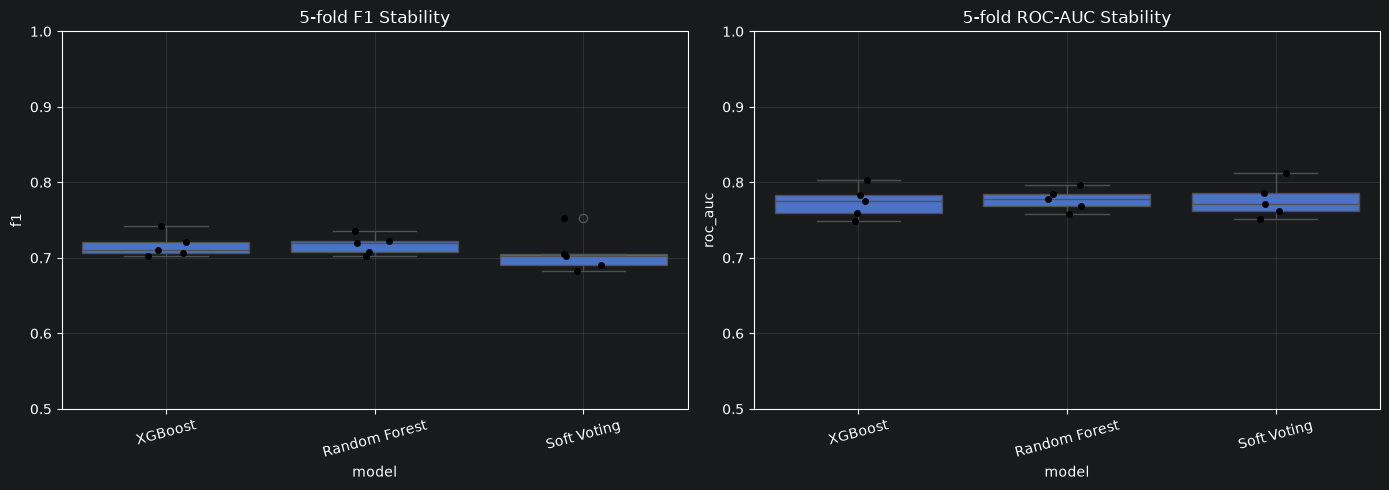

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=cross_validation_fold_df, x="model", y="f1", ax=axes[0])
sns.stripplot(data=cross_validation_fold_df, x="model", y="f1", color="black", size=5, ax=axes[0])
axes[0].set_title("5-fold F1 Stability")
axes[0].set_ylim(0.5, 1.0)
sns.boxplot(data=cross_validation_fold_df, x="model", y="roc_auc", ax=axes[1])
sns.stripplot(data=cross_validation_fold_df, x="model", y="roc_auc", color="black", size=5, ax=axes[1])
axes[1].set_title("5-fold ROC-AUC Stability")
axes[1].set_ylim(0.5, 1.0)
for axis in axes:
    axis.tick_params(axis="x", rotation=15)
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Out-of-Fold ROC와 Precision–Recall Curve

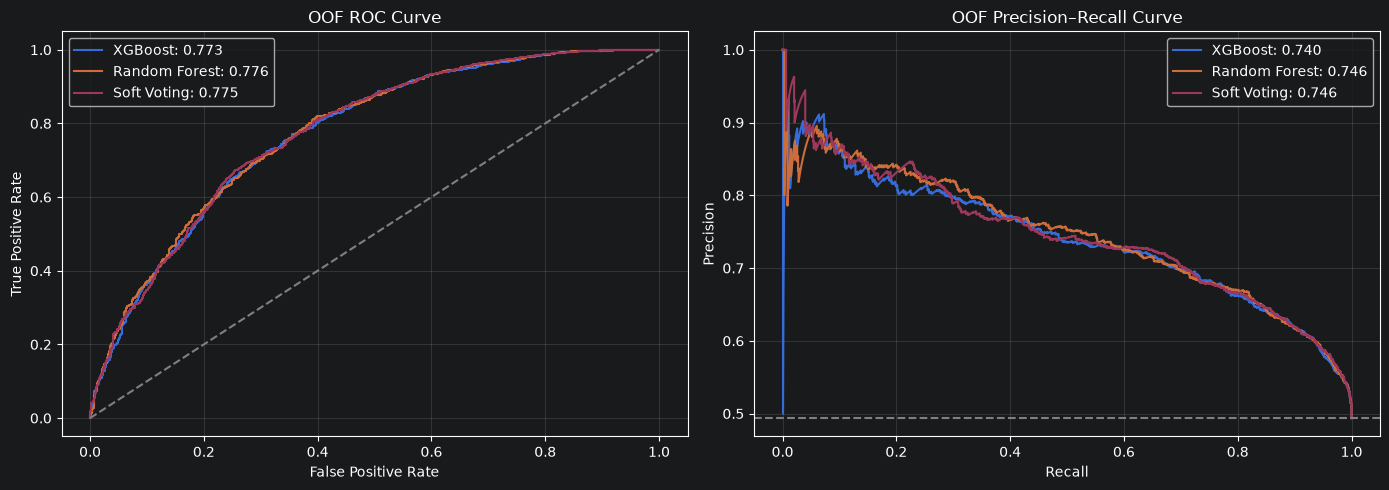

In [7]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, oof_proba in cross_validation_oof_probabilities.items():
    fpr, tpr, _ = roc_curve(y_train, oof_proba)
    precision, recall, _ = precision_recall_curve(y_train, oof_proba)
    axes[0].plot(fpr, tpr, label=f"{model_name}: {roc_auc_score(y_train, oof_proba):.3f}")
    axes[1].plot(recall, precision, label=f"{model_name}: {average_precision_score(y_train, oof_proba):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="OOF ROC Curve")
axes[1].axhline(y_train.mean(), linestyle="--", color="gray")
axes[1].set(xlabel="Recall", ylabel="Precision", title="OOF Precision–Recall Curve")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 7. 해석 기준 및 다음 단계

- `f1_mean`, `roc_auc_mean`이 높고 표준편차가 작을수록 안정적인 후보이다.
- `train_val_gap`이 크면 과적합 가능성을 의심한다.
- OOF 임계값 결과는 단일 Validation 임계값보다 Train 전체를 교차검증 방식으로 활용한 결과다.
- Soft Voting이 단일 모델보다 평균 성능을 개선하지 못하면 복잡성을 감수할 이유가 작다.
- 교차검증에서 가장 안정적인 1~2개 모델만 제한적으로 하이퍼파라미터 튜닝한다.
- 튜닝 후 기존 Validation 데이터에서 한 번 비교하고, 팀 합의로 최종 모델을 선택한 뒤 Test 데이터는 단 한 번 평가한다.